Дан датасет cifar100 https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR100.html
Это датасет для классификации изображений на 100 классов. В нем мы выбираем классы "мотоцикл" и "велосипед", остальное объявляем бэкграундом. Нужно решить задачу классификации изображений на эти три класса.

Условия:
1) Можно использовать любую претренированную модель
2) Не должно быть багов - решение должно выдавать результат, адекватный по точности для продакшена
Оценка 6 баллов за базовое решение без багов.
До -3 баллов за баги в зависимости от их критичности.
Допы:
1) Анализ результатов (confusion матрица, зависимость точности от внешних условий, сравнение моделей, анализ метрик, ...) + 1-2 балла в зависимости от полноты анализа
2) Трансформировать вручную без дообучения веса первого слоя так, чтобы сеть принимала grayscale изображения. Измерить точность на grayscale. +1 балл
3) 10 баллов за точность больше 99.9%

# Установка библиотек и импорт

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
from PIL import Image
import io

Looking in indexes: https://download.pytorch.org/whl/cu118


# Загрузка и подготовка датасета CIFAR100

In [2]:
# Определяем классы: bicycle (8), motorcycle (48), background (остальное)
BICYCLE_IDX = 8
MOTORCYCLE_IDX = 48
BACKGROUND_IDX = 2  # 0-байк, 1-мотоцикл, 2-бэкграунд

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

train_dataset_full = torchvision.datasets.CIFAR100(root='./data', train=True,
                                                  download=True, transform=transform_train)
test_dataset_full = torchvision.datasets.CIFAR100(root='./data', train=False,
                                                 download=True, transform=transform_test)

print(f"Полный train: {len(train_dataset_full)}, test: {len(test_dataset_full)}")

def filter_dataset(dataset, bicycle_idx, motorcycle_idx):
    indices = []
    new_targets = []
    for idx, target in enumerate(dataset.targets):
        if target == bicycle_idx:
            new_targets.append(0)
            indices.append(idx)
        elif target == motorcycle_idx:
            new_targets.append(1)
            indices.append(idx)
        else:
            new_targets.append(2)
            indices.append(idx)
    dataset.targets = torch.tensor(new_targets)
    return Subset(dataset, indices)

train_dataset = filter_dataset(train_dataset_full, BICYCLE_IDX, MOTORCYCLE_IDX)
test_dataset = filter_dataset(test_dataset_full, BICYCLE_IDX, MOTORCYCLE_IDX)

print(f"Фильтрованный train: {len(train_dataset)}, test: {len(test_dataset)}")
print(f"Распределение классов train: {torch.bincount(train_dataset.dataset.targets[:len(train_dataset)])}")


100%|██████████| 169M/169M [00:05<00:00, 28.5MB/s]


Полный train: 50000, test: 10000
Фильтрованный train: 50000, test: 10000
Распределение классов train: tensor([  500,   500, 49000])


# Создание DataLoader'ов

In [3]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Загрузка претренированной модели ResNet18

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

model = torchvision.models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)  # 3 класса
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Используем устройство: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


# Настройка обучения

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 20

#Функции для обучения и тестирования

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), correct / total

def test_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    return running_loss / len(loader), acc, all_preds, all_labels

# Обучение модели

In [7]:
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Эпоха {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}')
    print(f'  Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}')

Эпоха 1/20:
  Train Loss: 0.0717, Acc: 0.9816
  Test Loss: 0.0508, Acc: 0.9879
Эпоха 2/20:
  Train Loss: 0.0502, Acc: 0.9858
  Test Loss: 0.0408, Acc: 0.9883
Эпоха 3/20:
  Train Loss: 0.0453, Acc: 0.9867
  Test Loss: 0.0324, Acc: 0.9908
Эпоха 4/20:
  Train Loss: 0.0418, Acc: 0.9880
  Test Loss: 0.0316, Acc: 0.9904
Эпоха 5/20:
  Train Loss: 0.0400, Acc: 0.9884
  Test Loss: 0.0367, Acc: 0.9888
Эпоха 6/20:
  Train Loss: 0.0398, Acc: 0.9885
  Test Loss: 0.0328, Acc: 0.9914
Эпоха 7/20:
  Train Loss: 0.0448, Acc: 0.9879
  Test Loss: 0.0458, Acc: 0.9871
Эпоха 8/20:
  Train Loss: 0.0443, Acc: 0.9879
  Test Loss: 0.0285, Acc: 0.9915
Эпоха 9/20:
  Train Loss: 0.0379, Acc: 0.9893
  Test Loss: 0.0330, Acc: 0.9903
Эпоха 10/20:
  Train Loss: 0.0356, Acc: 0.9897
  Test Loss: 0.0254, Acc: 0.9921
Эпоха 11/20:
  Train Loss: 0.0261, Acc: 0.9923
  Test Loss: 0.0208, Acc: 0.9936
Эпоха 12/20:
  Train Loss: 0.0228, Acc: 0.9931
  Test Loss: 0.0190, Acc: 0.9937
Эпоха 13/20:
  Train Loss: 0.0213, Acc: 0.9933
  

# Визуализация обучения

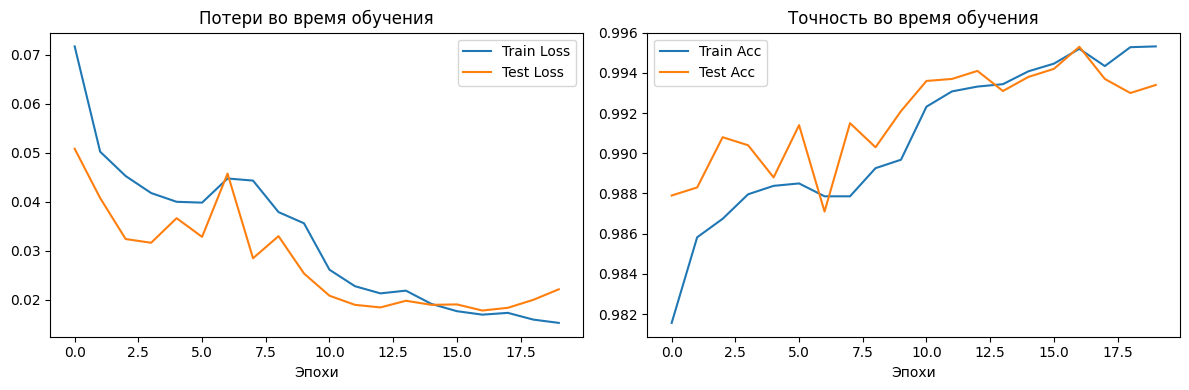

Финальная тестовая точность: 0.9934 (99.34%)


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title('Потери во время обучения')
plt.xlabel('Эпохи')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.legend()
plt.title('Точность во время обучения')
plt.xlabel('Эпохи')

plt.tight_layout()
plt.show()

final_test_acc = test_accs[-1]
print(f"Финальная тестовая точность: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")


# Анализ результатов (Confusion Matrix)

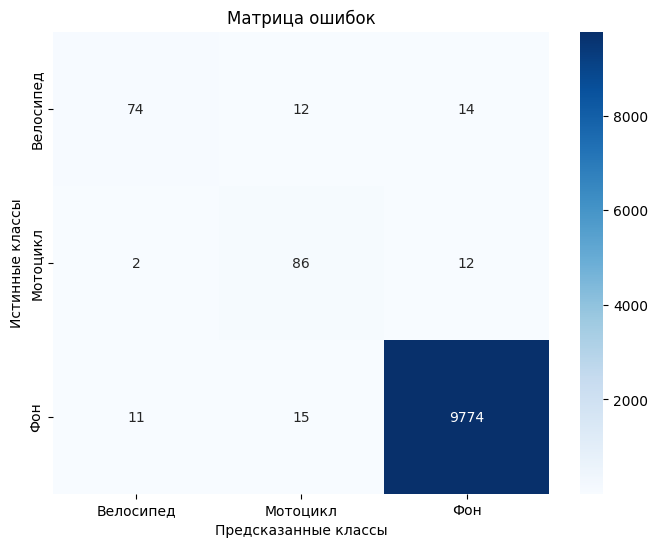


Отчет по классификации:
              precision    recall  f1-score   support

   Велосипед       0.85      0.74      0.79       100
    Мотоцикл       0.76      0.86      0.81       100
         Фон       1.00      1.00      1.00      9800

    accuracy                           0.99     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
_, _, all_preds, all_labels = test_epoch(model, test_loader, criterion, device)

class_names = ['Велосипед', 'Мотоцикл', 'Фон']
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

print("\nОтчет по классификации:")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ДОП: Grayscale

In [10]:
for param in model.parameters():
    param.requires_grad = False

old_conv1 = model.conv1
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
with torch.no_grad():
    model.conv1.weight = nn.Parameter(old_conv1.weight.mean(dim=1, keepdim=True))  # усредняем по каналам

# Обучаем только последний слой
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer_gray = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

transform_gray_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5071,), (0.2675,))  # усредненные статистики
])

test_dataset_gray = filter_dataset(
    torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_gray_test),
    BICYCLE_IDX, MOTORCYCLE_IDX
)
test_loader_gray = DataLoader(test_dataset_gray, batch_size=batch_size, shuffle=False)

# Тестирование на grayscale
model.eval()
test_loss_gray, acc_gray, preds_gray, labels_gray = test_epoch(model, test_loader_gray, criterion, device)

print(f"Точность на grayscale изображениях: {acc_gray:.4f} ({acc_gray*100:.2f}%)")
print(f"Сравнение: RGB {final_test_acc:.4f} vs Grayscale {acc_gray:.4f}")


Точность на grayscale изображениях: 0.9836 (98.36%)
Сравнение: RGB 0.9934 vs Grayscale 0.9836


# Визуализация предсказаний

ТЕСТИРОВАНИЕ RGB


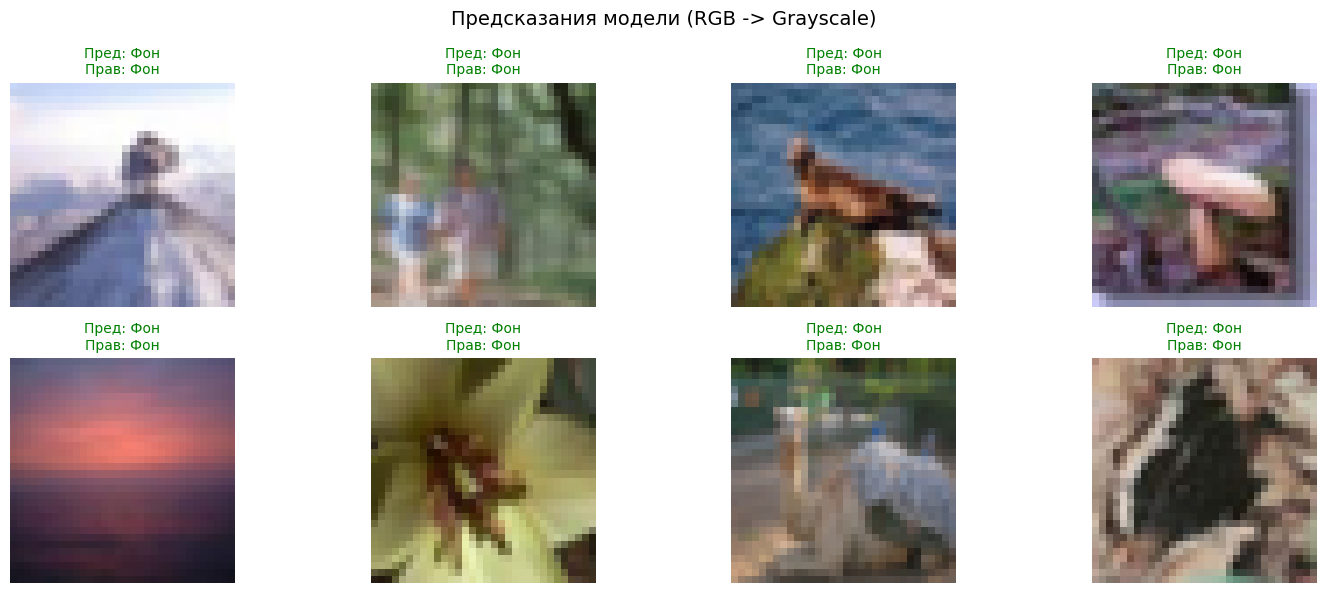

Точность на 8 примерах: 8/8 (100%)

ПРОВЕРКА GRAYSCALE ДАННЫХ


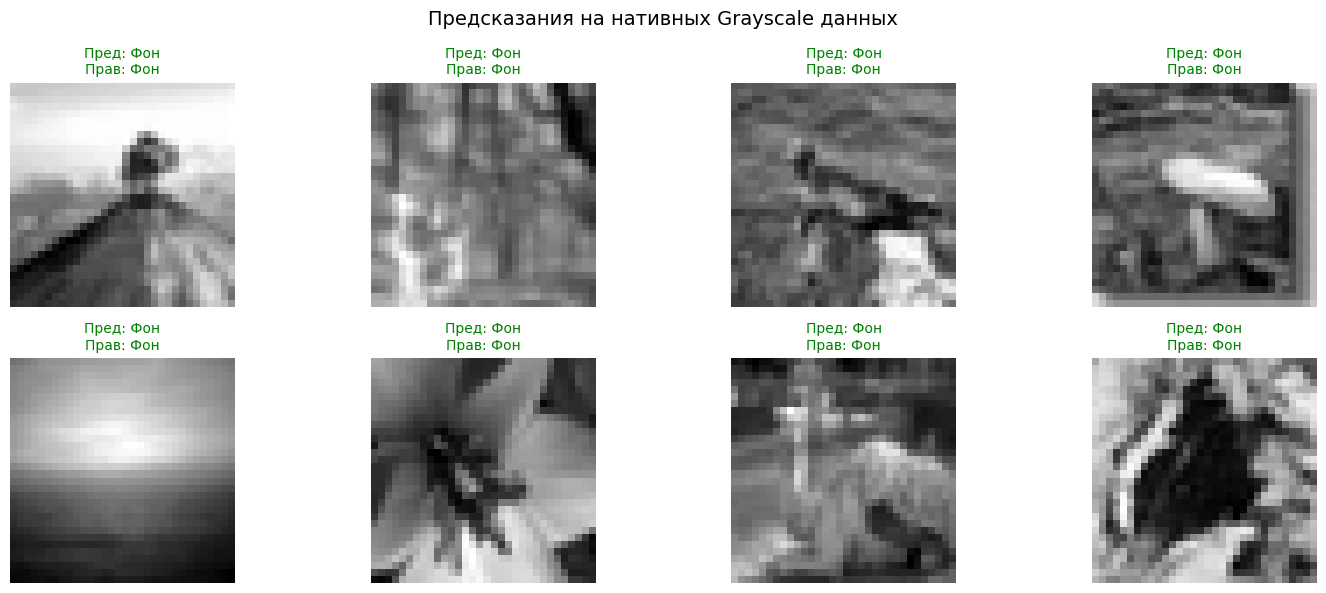

Точность на grayscale: 8/8 (100%)


In [11]:
def imshow(img, normalize=True, is_gray=False):
    img = img.clone().detach()
    if normalize:
        if is_gray:
            mean = torch.tensor([0.5071]).view(1, 1, 1).to(img.device)
            std = torch.tensor([0.2675]).view(1, 1, 1).to(img.device)
            img = img * std + mean
            npimg = img.cpu().numpy()[0]  # [H,W]
            plt.imshow(npimg, cmap='gray')
        else:
            mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(img.device)
            std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(img.device)
            img = img * std + mean
            npimg = img.cpu().numpy()
            plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

class_names = ['Велосипед', 'Мотоцикл', 'Фон']

print("ТЕСТИРОВАНИЕ RGB")
model.eval()  # текущая модель (grayscale)

# Берем данные из test_loader (RGB) и конвертируем в grayscale на лету
dataiter = iter(test_loader)
images_rgb, labels_rgb = next(dataiter)
images_rgb = images_rgb[:8].to(device)
labels_rgb = labels_rgb[:8].to(device)

# КОНВЕРТИРУЕМ RGB -> GRAYSCALE для текущей модели
images_gray_from_rgb = torch.mean(images_rgb, dim=1, keepdim=True)  # [B,1,H,W]

with torch.no_grad():
    outputs = model(images_gray_from_rgb)
    _, predicted = torch.max(outputs, 1)

# ВИЗУАЛИЗАЦИЯ
fig = plt.figure(figsize=(15, 6))
for idx in range(8):
    ax = fig.add_subplot(2, 4, idx+1)
    imshow(images_rgb[idx], normalize=True, is_gray=False)
    pred = class_names[predicted[idx]]
    true_label = class_names[labels_rgb[idx]]
    color = 'green' if predicted[idx] == labels_rgb[idx] else 'red'
    ax.set_title(f'Пред: {pred}\nПрав: {true_label}', color=color, fontsize=10)
plt.suptitle('Предсказания модели (RGB -> Grayscale)', fontsize=14)
plt.tight_layout()
plt.show()

# СТАТИСТИКА
correct = (predicted == labels_rgb).sum().item()
print(f"Точность на 8 примерах: {correct}/8 ({correct/8*100:.0f}%)")

print("\nПРОВЕРКА GRAYSCALE ДАННЫХ")
dataiter_gray = iter(test_loader_gray)
images_gray, labels_gray = next(dataiter_gray)
images_gray = images_gray[:8].to(device)
labels_gray = labels_gray[:8].to(device)

with torch.no_grad():
    outputs_gray = model(images_gray)
    _, predicted_gray = torch.max(outputs_gray, 1)

fig2 = plt.figure(figsize=(15, 6))
for idx in range(8):
    ax = fig2.add_subplot(2, 4, idx+1)
    imshow(images_gray[idx], normalize=True, is_gray=True)
    pred = class_names[predicted_gray[idx]]
    true_label = class_names[labels_gray[idx]]
    color = 'green' if predicted_gray[idx] == labels_gray[idx] else 'red'
    ax.set_title(f'Пред: {pred}\nПрав: {true_label}', color=color, fontsize=10)
plt.suptitle('Предсказания на нативных Grayscale данных', fontsize=14)
plt.tight_layout()
plt.show()

correct_gray = (predicted_gray == labels_gray).sum().item()
print(f"Точность на grayscale: {correct_gray}/8 ({correct_gray/8*100:.0f}%)")
